# Tidal Disruption Threshold in Black Hole–Neutron Star Mergers

## Overview

This tutorial computes the **minimum aligned black hole spin** required for tidal disruption of a neutron star (NS) in a black hole–neutron star (BHNS) merger that produces observable ejecta.

### Key Physics

In BHNS mergers, whether the NS is tidally disrupted depends on:
- **Black hole mass** ($M_{\text{BH}}$) and **neutron star mass** ($M_{\text{NS}}$), through the **mass ratio** $q = M_{\text{BH}} / M_{\text{NS}}$
- **Neutron star compactness** $C = \frac{G M_{\text{NS}}}{R_{\text{NS}} c^2}$, which depends on the **equation of state (EoS)**
- **Black hole spin** $\chi_{\text{BH}}$ (aligned with orbital angular momentum)

Tidal disruption occurs when the neutron star is torn apart by tidal forces before crossing the black hole's event horizon. The resulting ejecta can power electromagnetic counterparts (kilonovae, X-ray flares).

### Methodology

Following **Foucart (2018, 2020)** and the usage in Colombo et al. (2024), we track:
1. **Remnant baryon mass (preferred):** Foucart 2018 model $\hat{M}_{\mathrm{rem}}(C, q, \chi_{\text{BH}})$ with symmetric-mass-ratio scaling
2. **Dynamical ejecta:** Foucart 2020 $M_{\text{dyn}}(C, q, \chi_{\text{BH}})$ kept as complementary diagnostic 

In this notebook, the reported **disruption threshold** $\chi_{\text{min}}$ is computed from the Foucart 2018 remnant-mass condition $\hat{M}_{\mathrm{rem}} > 0$.

### Equations of State

We compare two EoSs:
- **SFHo** (HSNP 2010, SHF 2013): relatively soft, predicts lower maximum NS masses
- **DD2** (TRKBP 2010): relatively stiff, predicts higher maximum NS masses

These give different mass–radius relations, hence different compactness values and disruption thresholds.

NEUTRON STAR PROPERTIES (interpolated from EoS tables)
Requested NS Masses (M_sun): [1.  1.4 2. ]
Clipped to SFHo TOV limit (M_sun): [1.  1.4 2. ]
Clipped to DD2 TOV limit (M_sun): [1.  1.4 2. ]

Interpolated Radii (km) - SFHo: [12.04089122 11.92418176 11.00663609]
Interpolated Radii (km) - DD2: [13.1179299  13.26412414 13.19765359]

Compactness [M_sun/km] - SFHo: [0.08305033 0.11740848 0.18170856]
Compactness [M_sun/km] - DD2: [0.07623154 0.10554787 0.15154209]


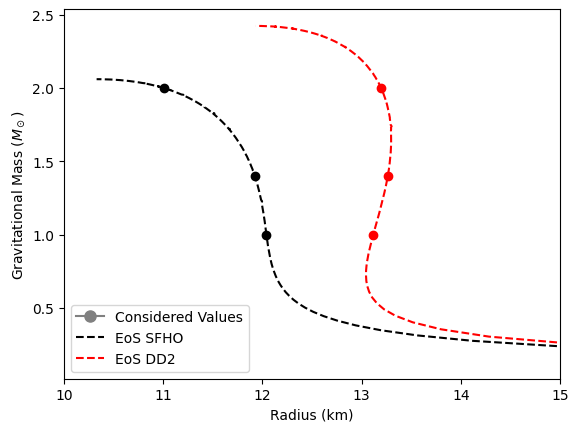

In [1]:
import  numpy as np
import  matplotlib.pyplot as plt
from    scipy.optimize import bisect
import  pandas as pd

# Define NS–BH binary pairs: [M_NS (M_sun), M_BH (M_sun)]
mass_pairs = np.array([
    [1.0, 5.0],      
    [1.4, 10.0],     
    [2.0, 20.0]      
])

# Load EoS mass–radius tables
# File format: columns = [Radius (km), Mass (M_sun)], no header
eos_sfho_rad_mass       = np.loadtxt("eos_sfho.mr", skiprows=1)
rad_sfho, mass_sfho     = eos_sfho_rad_mass[:, 0], eos_sfho_rad_mass[:, 1]

eos_dd2_rad_mass        = np.loadtxt("eos_dd2.mr", skiprows=1)
rad_dd2, mass_dd2       = eos_dd2_rad_mass[:, 0], eos_dd2_rad_mass[:, 1]

# Extract NS masses from binary pairs
bns_masses              = mass_pairs[:, 0]

# Get maximum NS mass for each EoS (TOV limit, dependent on EoS)
max_mass_sfho           = max(mass_sfho)
max_mass_dd2            = max(mass_dd2)

# Clip requested masses to available EoS range
# (handles case where a requested mass exceeds the TOV limit)
bns_masses_sfho         = np.clip(bns_masses, None, max_mass_sfho)
bns_masses_dd2          = np.clip(bns_masses, None, max_mass_dd2)

# Interpolate radius at each NS mass for both EoSs
rad_interp_sfho         = np.interp(bns_masses_sfho, mass_sfho, rad_sfho)
rad_interp_dd2          = np.interp(bns_masses_dd2, mass_dd2, rad_dd2)

# Compute dimensionless NS compactness C = (G M_NS / c^2) / R_NS
# Here we use an intermediate unit: [M_sun / km]
# Full conversion to dimensionless is done later
compactness_sfho        = bns_masses_sfho / rad_interp_sfho
compactness_dd2         = bns_masses_dd2 / rad_interp_dd2

print("=" * 60)
print("NEUTRON STAR PROPERTIES (interpolated from EoS tables)")
print("=" * 60)
print("Requested NS Masses (M_sun):", bns_masses)
print("Clipped to SFHo TOV limit (M_sun):", bns_masses_sfho)
print("Clipped to DD2 TOV limit (M_sun):", bns_masses_dd2)
print()
print("Interpolated Radii (km) - SFHo:", rad_interp_sfho)
print("Interpolated Radii (km) - DD2:", rad_interp_dd2)
print()
print("Compactness [M_sun/km] - SFHo:", compactness_sfho)
print("Compactness [M_sun/km] - DD2:", compactness_dd2)

color_sfho  = 'k'
color_dd2   = 'r'

plt.scatter(rad_interp_sfho, bns_masses_sfho, color=color_sfho)
plt.scatter(rad_interp_dd2, bns_masses_dd2, color=color_dd2)
plt.plot(rad_sfho, mass_sfho, color=color_sfho, linestyle="--")
plt.plot(rad_dd2, mass_dd2, color=color_dd2, linestyle="--")
plt.xlabel("Radius (km)")
plt.ylabel("Gravitational Mass $(M_\\odot)$")

legend_handles = [
    plt.Line2D([0], [0], marker='o', color='gray', label='Considered Values', markersize=8),
    plt.Line2D([0], [0], color=color_sfho, linestyle="--", label='EoS SFHO'),
    plt.Line2D([0], [0], color=color_dd2, linestyle="--", label='EoS DD2')
]
plt.legend(handles=legend_handles)
plt.xlim(10, 15)
plt.savefig("mass_radius_plot.pdf", dpi=300)
plt.show()

## Part 1: Load Equation of State Data and Visualize Mass–Radius Relations

In this section, we:
1. Load tabulated mass vs. radius data for two EoSs from `.mr` files (obtain more EOS at https://compose.obspm.fr/eos/2, https://compose.obspm.fr/eos/14)
2. Define a few target NS masses spanning the range of interest
3. Interpolate radii at these masses
4. Visualize the EoS curves and target masses on a mass–radius diagram

The data files contain columns: `[Radius (km), Mass (M☉)]`

In [2]:
# ============================================================
# PART 2: FOUCART FITTING FORMULAE FOR MERGER EJECTA
# ============================================================

# Conversion factor used in your population files when compactness is stored in M_sun / R_sun.
# Dimensionless compactness is C = C_data * COMPACTNESS_CONV.
COMPACTNESS_CONV = 1476.625 / 6.957e8  # ~2.1226e-6

# For radii in km (like rad_interp_sfho, rad_interp_dd2):
# C = (G M_sun / c^2) * (M_ns / R_ns[km]) with G M_sun / c^2 = 1.476625 km.
COMPACTNESS_CONV_KM = 1.476625

# Numerical threshold for "non-zero ejecta" (basically zero, for numerical stability)
MREM_EPS = 1e-12

def foucart_dynamical_ejecta(C_ns, q, chi_bh):
    """Foucart (2020) dynamical ejecta mass fraction for a BHNS merger.
    
    **COMPLEMENTARY DIAGNOSTIC** (kept alongside remnant-mass fits)
    
    We keep this fit to track dynamical ejecta in parallel with remnant-mass
    criteria. It is not the default threshold model in this notebook.
    
    Parameters
    ----------
    C_ns   : float or array
        Dimensionless NS compactness.
    q      : float or array
        Mass ratio q = M_BH / M_NS.
    chi_bh : float
        Dimensionless BH spin.
        
    Returns
    -------
    float or array
        M_dyn / M_baryon_ns (fraction of dynamically ejected mass), clipped to >= 0.
        We define disruption threshold as M_dyn > 0.
    """
    # Compute ISCO radius from BH spin (Bardeen et al. 1972)
    z1 = 1 + (1 - chi_bh**2) ** (1 / 3) * (
        (1 + chi_bh) ** (1 / 3) + (1 - chi_bh) ** (1 / 3)
    )
    z2 = np.sqrt(3 * chi_bh**2 + z1**2)
    risco_m = 3 + z2 - np.sign(chi_bh) * np.sqrt((3 - z1) * (3 + z1 + 2 * z2))

    # Fit parameters from Foucart (2020), calibrated against GRMHD simulations
    a1 = 0.007116   # Tidal effect coefficient
    a2 = 0.001436   # ISCO capture coefficient
    a4 = -0.02762   # Constant offset
    n1 = 0.8636     # Tidal power-law exponent
    n2 = 1.6840     # ISCO power-law exponent

    # Two dominant contributions:
    # term1: Tidal disruption (higher for lower compactness, higher mass ratio)
    term1 = a1 * (q**n1) * ((1 - 2 * C_ns) / C_ns)
    # term2: ISCO accretion (material closer to ISCO is more easily consumed by BH)
    term2 = a2 * (q**n2) * risco_m #! This is already divided by M_BH/in units of M_BH
    
    m_dyn = term1 - term2 + a4
    return np.maximum(0.0, m_dyn)

def foucart_remnant_mass(C_ns, q, chi_bh):
    """Foucart (2018) remnant mass fraction outside the BH after a BHNS merger.

    The fraction of baryon mass remaining outside the black hole determines whether
    electromagnetic counterparts can be produced. Lower remnant mass → less ejecta.

    Parameters
    ----------
    C_ns   : float or array
        Dimensionless NS compactness C = G M_NS / (R_NS c^2), typical ~0.14-0.20.
    q      : float or array
        Mass ratio q = M_BH / M_NS (higher mass ratio favors disruption).
    chi_bh : float
        Dimensionless BH spin (-1 to 1, aligned with orbital angular momentum).
        Higher spin → smaller ISCO → more material swallowed.

    Returns
    -------
    float or array
        M_rem / M_baryon_ns (fraction of baryon mass remaining outside BH), clipped to >= 0.
        
    Notes
    -----
    This is the primary remnant-mass model used in this notebook.
    It replaces the strict high-q scaling with eta = q/(1+q)^2, improving
    behavior away from the Q -> infinity limit.
    """
    # Bardeen et al. (1972) ISCO radius in units of M_BH
    # ISCO shrinks with increasing spin, pulling material inside the event horizon
    z1 = 1 + (1 - chi_bh**2)**(1 / 3) * ((1 + chi_bh)**(1 / 3) + (1 - chi_bh)**(1 / 3))
    z2 = np.sqrt(3 * chi_bh**2 + z1**2)
    risco_m = 3 + z2 - np.sign(chi_bh) * np.sqrt((3 - z1) * (3 + z1 + 2 * z2))
    eta = q / (1 + q)**2  # Symmetric mass ratio
    # In the high-q limit, eta ~ q^{-1}, recovering the reference large-Q scaling

    # Fit parameters from Foucart 2018 remnant-mass calibration
    # (obtained by minimizing normalized residuals to NR results)
    alpha = 0.406  # Tidal disruption term coefficient
    beta = 0.139   # ISCO term coefficient
    gamma = 0.255 
    delta = 1.761

    # Two competing terms:
    # term1: Tidal effect on the NS (higher for lower C, higher q)
    # term2: Matter lost through ISCO (higher for higher chi, higher q, higher C)
    #term1 = alpha * (3 * q) ** (1 / 3) * (1 - 2 * C_ns)
    #term2 = beta * risco_m * q * C_ns
    #m_rem = term1 - term2
    
    term1 = alpha * eta**(-1/3) * (1 - 2 * C_ns)
    term2 = beta * eta**(-1) * risco_m * C_ns
    term3 = gamma 

    m_rem = term1 - term2 + term3 
    m_rem = np.maximum(0.0, m_rem)**delta

    return m_rem

def min_spin_for_disruption(C_ns, q, eps=MREM_EPS, chi_min=0.0, chi_max=0.999, max_iter=80):
    """Find the minimum BH spin for non-zero ejecta using bisection.
    
    This solves for the spin χ_min such that M_rem(χ_min) ≈ ε,
    where ε is a small numerical threshold. If even the maximum spin
    χ_max yields M_rem = 0, no disruption is possible and we return NaN.

    Parameters
    ----------
    C_ns      : float or array
        Dimensionless NS compactness.
    q         : float or array
        Mass ratio q = M_BH / M_NS.
    eps       : float, optional
        Ejecta threshold (default: 1e-12).
    chi_min   : float, optional
        Lower search bound (default: 0.0).
    chi_max   : float, optional
        Upper search bound (default: 0.999).
    max_iter  : int, optional
        Max bisection iterations (default: 80).

    Returns
    -------
    float
        Minimum spin in [chi_min, chi_max] if disruption is possible.
        NaN if no disruption occurs even at chi_max.
    """
    m_low = foucart_remnant_mass(C_ns, q, chi_min)
    if m_low > eps:
        return chi_min

    m_high = foucart_remnant_mass(C_ns, q, chi_max)
    if m_high <= eps:
        return np.nan

    func_to_bisect      = lambda chi: foucart_remnant_mass(C_ns, q, chi) - eps
    chi_min_disruption  = bisect(func_to_bisect, chi_min, chi_max, xtol=1e-5, maxiter=max_iter)

    return chi_min_disruption

# Build NS-BH couples from the notebook arrays:
# mass_pairs[:, 0] = NS mass [M_sun], mass_pairs[:, 1] = BH mass [M_sun]
ns_masses   = mass_pairs[:, 0]
bh_masses   = mass_pairs[:, 1]
q_pairs     = bh_masses / ns_masses

# Compactness from interpolated radii in km
# C = (G M_sun / c^2) * (M_ns / R_ns[km]) where G M_sun/c^2 = 1.476625 km
C_sfho_dimless  = COMPACTNESS_CONV_KM * (ns_masses / rad_interp_sfho)
C_dd2_dimless   = COMPACTNESS_CONV_KM * (ns_masses / rad_interp_dd2)

header = (
    "i  M_NS  M_BH    q      C_SFHO   χ_min_SFHO   C_DD2    χ_min_DD2"
)
print(header)
print("-" * len(header))

header = [
    "i", "M_NS (M_sun)", "M_BH (M_sun)", "q", 
    "C_SFHO", "χ_min_SFHO", "C_DD2", "χ_min_DD2"
]

df_results = pd.DataFrame(columns=header)
df_results["i"] = np.arange(1, len(ns_masses) + 1)
df_results["M_NS (M_sun)"] = ns_masses
df_results["M_BH (M_sun)"] = bh_masses
df_results["q"] = q_pairs
df_results["C_SFHO"] = C_sfho_dimless
df_results["C_DD2"] = C_dd2_dimless
df_results["χ_min_SFHO"] = [min_spin_for_disruption(c, q) for c, q in zip(C_sfho_dimless, q_pairs)]
df_results["χ_min_DD2"] = [min_spin_for_disruption(c, q) for c, q in zip(C_dd2_dimless, q_pairs)]
    
display(df_results)

i  M_NS  M_BH    q      C_SFHO   χ_min_SFHO   C_DD2    χ_min_DD2
----------------------------------------------------------------


,i,M_NS (M_sun),M_BH (M_sun),q,C_SFHO,χ_min_SFHO,C_DD2,χ_min_DD2
0,1,1.0,5.0,5.000000,0.122634,0.000000,0.112565,0.000000
1,2,1.4,10.0,7.142857,0.173368,0.646379,0.155855,0.511352
2,3,2.0,20.0,10.000000,0.268315,0.986173,0.223771,0.937317


## Part 2: Foucart Fitting Formulae for Merger Ejecta

**Primary remnant-mass model:** Foucart et al. (2018); setup motivated by high-$Q$ arguments and used in Colombo et al. (2024)

### Remnant Baryon Mass (Foucart 2018)

We use the Foucart 2018 remnant-mass fit as the main disruption diagnostic:
$$\hat{M}^{\rm rem} = \left[\max\left(\alpha \frac{1-2C_{\rm NS}}{\eta^{1/3}} - \beta \hat{R}_{\rm ISCO}\frac{C_{\rm NS}}{\eta} + \gamma,\,0\right)\right]^\delta$$

where:
- $\eta = q/(1+q)^2$ is the symmetric mass ratio
- $\hat{R}_{\rm ISCO}(\chi)$ is the Kerr ISCO radius in units of $M_{\rm BH}$
- best-fit coefficients are $\alpha=0.406$, $\beta=0.139$, $\gamma=0.255$, $\delta=1.761$

This model restores the two-body symmetry through $\eta$ and is typically more accurate than the pure large-$q$ scaling when approaching moderate mass ratios.

**Disruption Threshold:** $\chi_{\text{min}}$ is the minimum BH spin where $\hat{M}^{\rm rem} > 0$.

### Dynamical Ejecta (Foucart 2020) — COMPLEMENTARY

We also keep the Foucart 2020 dynamical ejecta fit:
$$M_{\text{dyn}} = a_1 q^{n_1} \frac{1 - 2C}{C} - a_2 q^{n_2} r_{\text{ISCO}}(\chi) + a_4$$

with $a_1 = 0.007116$, $a_2 = 0.001436$, $a_4 = -0.02762$, $n_1 = 0.8636$, $n_2 = 1.6840$.
We use it as a complementary ejecta diagnostic alongside the remnant-mass threshold.

### Physics Intuition

Both formulas involve competition between two effects:
1. **Tidal disruption** (first term): NSs with lower compactness are easier to disrupt
2. **ISCO capture** (second term): Higher BH spins shrink the ISCO, consuming material before it can escape

The threshold $\chi_{\text{min}}$ is found using **bisection**: we search for the minimum spin where the chosen ejecta/remnant criterion first becomes positive.

## Part 3: Reverse Engineering: Choosing BH Masses for Fixed NS Masses

### Motivation

In the previous section, we fixed **binary masses** and computed the disruption threshold. Here we flip the problem:
- **Fix** the neutron star mass
- **Vary** the black hole mass (integer values for simplicity)
- **Find** BH masses that produce a disruption threshold near a target spin

### Use Cases

**Case 1:** $M_{\text{NS}}=1.0\,M_\odot$ is the baseline row used in the LaTeX summary table
**Case 2:** $M_{\text{NS}}=1.5\,M_\odot$, find $M_{\text{BH}}$ such that disruption occurs near $\chi\approx0.5$
**Case 3:** $M_{\text{NS}}=2.0\,M_\odot$, find $M_{\text{BH}}$ such that disruption threshold is near $\chi\approx0.9$

### Outputs

For each $(M_{\text{NS}}, M_{\text{BH}})$ pair, we compute:
- Chirp mass $\mathcal{M}_c = \frac{(M_1 M_2)^{3/5}}{(M_1+M_2)^{1/5}}$ (relevant for GW detections)
- NS radius from each EoS
- NS compactness from each EoS
- Minimum BH spin $\chi_{\min}$ for disruption
- Whether disruption is possible at the target spin

At the end of the section, the notebook also prints a LaTeX table for direct use in the manuscript.

In [3]:
# ============================================================================
# PART 3: REVERSE ENGINEERING - Find BH masses for target disruption spins
# ============================================================================

def ns_compactness_from_eos(m_ns, mass_grid, rad_grid_km):
    """Compute NS compactness C = (G M / c^2) / R from EoS table.
    
    Parameters
    ----------
    m_ns : float
        Neutron star mass [M_sun]
    mass_grid : array
        EoS mass column [M_sun]
    rad_grid_km : array
        EoS radius column [km]
        
    Returns
    -------
    C : float
        Dimensionless compactness
    r_km : float
        Radius [km] at the given mass
    """
    m_clip  = np.clip(m_ns, np.min(mass_grid), np.max(mass_grid))
    r_km    = np.interp(m_clip, mass_grid, rad_grid_km)
    return COMPACTNESS_CONV_KM * (m_clip / r_km), r_km

def chirp_mass(m1, m2):
    """Compute the chirp mass of a binary.
    
    Relevant for gravitational wave detection and signal-to-noise ratio.
    """
    return (m1 * m2) ** (3.0 / 5.0) / (m1 + m2) ** (1.0 / 5.0)

def scan_integer_bh_masses(m_ns, target_spin, mbh_min=5, mbh_max=30):
    """Scan integer BH masses and compute disruption thresholds.
    
    For each integer M_BH in [mbh_min, mbh_max], compute:
    - Mass ratio q = M_BH / M_NS
    - Chirp mass
    - NS radius and compactness from both EoSs
    - Minimum disruption spin for both EoSs
    
    Then identify special candidates (best from below, widest chirp, closest to target).
    
    Parameters
    ----------
    m_ns : float
        Fixed neutron star mass [M_sun]
    target_spin : float
        Target disruption spin (e.g., 0.5 or 0.9)
    mbh_min, mbh_max : int
        Range of integer BH masses to scan
        
    Returns
    -------
    df : pandas.DataFrame
        Full scan results with columns for each computed quantity
    summary : dict
        Special cases: best candidates from different selection criteria
    """
    
    # Get NS compactness and radius for this M_NS from each EoS
    c_sfho, r_sfho  = ns_compactness_from_eos(m_ns, mass_sfho, rad_sfho)
    c_dd2, r_dd2    = ns_compactness_from_eos(m_ns, mass_dd2, rad_dd2)

    header = ["M_NS", "M_BH", "q", "M_chirp", "R_NS_SFHO_km", "R_NS_DD2_km", "C_SFHO", "C_DD2", "chi_min_SFHO", "chi_min_DD2", "ejecta_at_target_SFHO", "ejecta_at_target_DD2"]
    df_test = pd.DataFrame(columns=header) # testing avoiding for loops
    df_test["M_NS"]     = m_ns * np.ones(mbh_max - mbh_min + 1)
    df_test["M_BH"]     = np.arange(mbh_min, mbh_max + 1)
    df_test["q"]        = df_test["M_BH"] / m_ns
    df_test["M_chirp"]  = chirp_mass(df_test["M_NS"], df_test["M_BH"])
    df_test["R_NS_SFHO_km"] = r_sfho
    df_test["R_NS_DD2_km"] = r_dd2
    df_test["C_SFHO"] = c_sfho
    df_test["C_DD2"] = c_dd2
    df_test["chi_min_SFHO"] = df_test.apply(lambda row: min_spin_for_disruption(row["C_SFHO"], row["q"]), axis=1)
    df_test["chi_min_DD2"] = df_test.apply(lambda row: min_spin_for_disruption(row["C_DD2"], row["q"]), axis=1)
    df_test["ejecta_at_target_SFHO"] = df_test.apply(lambda row: np.isfinite(row["chi_min_SFHO"]) and (row["chi_min_SFHO"] <= target_spin), axis=1)
    df_test["ejecta_at_target_DD2"] = df_test.apply(lambda row: np.isfinite(row["chi_min_DD2"]) and (row["chi_min_DD2"] <= target_spin), axis=1)
    df = df_test
    # ========================================================================
    # Selection criteria for recommended systems
    # ========================================================================
    
    # Best from below: highest chi_min ≤ target_spin (most robust to uncertainty)
    def best_from_below(col):
        ok = df[np.isfinite(df[col]) & (df[col] <= target_spin)].copy()
        if ok.empty:
            return None
        ok["dist"] = target_spin - ok[col]
        # Sort by: distance from target (ascending), then M_BH (descending for latest BH)
        return ok.sort_values(["dist", "M_BH"], ascending=[True, False]).iloc[0]

    # Widest chirp: largest chirp mass among systems that disrupt at target spin
    def widest_chirp(col):
        ok = df[np.isfinite(df[col]) & (df[col] <= target_spin)]
        if ok.empty:
            return None
        return ok.sort_values("M_chirp", ascending=False).iloc[0]

    # Closest overall: closest to target spin (even if slightly above it)
    # Useful for "target near 0.9" where slightly-above might be acceptable
    def closest_overall(col):
        ok = df[np.isfinite(df[col])].copy()
        if ok.empty:
            return None
        ok["absdist"] = np.abs(ok[col] - target_spin)
        return ok.sort_values(["absdist", "M_BH"], ascending=[True, True]).iloc[0]

    summary = {
        "best_below_sfho": best_from_below("chi_min_SFHO"),
        "best_below_dd2": best_from_below("chi_min_DD2"),
        "widest_sfho": widest_chirp("chi_min_SFHO"),
        "widest_dd2": widest_chirp("chi_min_DD2"),
        "closest_all_sfho": closest_overall("chi_min_SFHO"),
        "closest_all_dd2": closest_overall("chi_min_DD2"),
    }

    return df, summary

def print_pick(label, row, chi_col):
    """Pretty-print a recommended system."""
    if row is None:
        print(f"{label}: no integer BH mass in scan range")
        return
    print(
        f"{label}: M_NS={row['M_NS']:.1f}, M_BH={int(row['M_BH'])}, "
        f"q={row['q']:.2f}, M_chirp={row['M_chirp']:.3f}, "
        f"{chi_col}={row[chi_col]:.5f}"
    )


# ============================================================================
# EXECUTE SCANS FOR CASES 2 AND 3
# ============================================================================

# Keep case 1 unchanged (from earlier): M_NS=1.0, M_BH=5

# Case 2 parameters
target_case2 = 0.5
mns_case2 = 1.5

# Case 3 parameters
target_case3 = 0.9
mns_case3 = 2.0

print("\n" + "=" * 70)
print("CASE 2: Fixed M_NS = 1.5 M_☉, target disruption spin ≈ 0.5")
print("=" * 70)
case2_df, case2_sum = scan_integer_bh_masses(mns_case2, target_case2, mbh_min=4, mbh_max=30)

print("\n" + "=" * 70)
print("CASE 3: Fixed M_NS = 2.0 M_☉, target disruption spin ≈ 0.9")
print("=" * 70)
case3_df, case3_sum = scan_integer_bh_masses(mns_case3, target_case3, mbh_min=4, mbh_max=30)

# Print recommendations
print("\n" + "-" * 70)
print("RECOMMENDED SYSTEMS")
print("-" * 70)

print("\n--- Case 2: M_NS = 1.5, target spin ≈ 0.5 ---")
print_pick("SFHo (closest from below)", case2_sum["best_below_sfho"], "chi_min_SFHO")
print_pick("DD2  (closest from below)", case2_sum["best_below_dd2"], "chi_min_DD2")
print_pick("SFHo (widest chirp @ 0.5)", case2_sum["widest_sfho"], "chi_min_SFHO")
print_pick("DD2  (widest chirp @ 0.5)", case2_sum["widest_dd2"], "chi_min_DD2")

print("\n--- Case 3: M_NS = 2.0, target spin ≈ 0.9 ---")
print_pick("SFHo (closest to 0.9)", case3_sum["closest_all_sfho"], "chi_min_SFHO")
print_pick("DD2  (closest to 0.9)", case3_sum["closest_all_dd2"], "chi_min_DD2")
print_pick("SFHo (closest below 0.9)", case3_sum["best_below_sfho"], "chi_min_SFHO")
print_pick("DD2  (closest below 0.9)", case3_sum["best_below_dd2"], "chi_min_DD2")

# Display sample tables
print("\n" + "-" * 70)
print("SAMPLE DATA TABLES (first 12 rows)")
print("-" * 70)
print("\nCase 2 (M_NS = 1.5):")
display(case2_df[["M_NS", "M_BH", "q", "M_chirp", "chi_min_SFHO", "chi_min_DD2"]].head(12))

print("\nCase 3 (M_NS = 2.0):")
display(case3_df[["M_NS", "M_BH", "q", "M_chirp", "chi_min_SFHO", "chi_min_DD2"]].head(12))


CASE 2: Fixed M_NS = 1.5 M_☉, target disruption spin ≈ 0.5

CASE 3: Fixed M_NS = 2.0 M_☉, target disruption spin ≈ 0.9

----------------------------------------------------------------------
RECOMMENDED SYSTEMS
----------------------------------------------------------------------

--- Case 2: M_NS = 1.5, target spin ≈ 0.5 ---
SFHo (closest from below): M_NS=1.5, M_BH=6, q=4.00, M_chirp=2.498, chi_min_SFHO=0.44030
DD2  (closest from below): M_NS=1.5, M_BH=8, q=5.33, M_chirp=2.831, chi_min_DD2=0.42914
SFHo (widest chirp @ 0.5): M_NS=1.5, M_BH=6, q=4.00, M_chirp=2.498, chi_min_SFHO=0.44030
DD2  (widest chirp @ 0.5): M_NS=1.5, M_BH=8, q=5.33, M_chirp=2.831, chi_min_DD2=0.42914

--- Case 3: M_NS = 2.0, target spin ≈ 0.9 ---
SFHo (closest to 0.9): M_NS=2.0, M_BH=10, q=5.00, M_chirp=3.671, chi_min_SFHO=0.90271
DD2  (closest to 0.9): M_NS=2.0, M_BH=16, q=8.00, M_chirp=4.488, chi_min_DD2=0.89558
SFHo (closest below 0.9): M_NS=2.0, M_BH=9, q=4.50, M_chirp=3.507, chi_min_SFHO=0.88284
DD2  (clos

,M_NS,M_BH,q,M_chirp,chi_min_SFHO,chi_min_DD2
0,1.5,4,2.666667,2.083619,0.212868,0.000000
1,1.5,5,3.333333,2.303849,0.337896,0.108237
2,1.5,6,4.000000,2.497660,0.440302,0.236679
3,1.5,7,4.666667,2.671959,0.523791,0.342118
4,1.5,8,5.333333,2.831157,0.592173,0.429143
5,1.5,9,6.000000,2.978259,0.648650,0.501565
6,1.5,10,6.666667,3.115410,0.695707,0.562372
7,1.5,11,7.333333,3.244206,0.735234,0.613849
8,1.5,12,8.000000,3.365865,0.768708,0.657812
9,1.5,13,8.666667,3.481346,0.797244,0.695600



Case 3 (M_NS = 2.0):


,M_NS,M_BH,q,M_chirp,chi_min_SFHO,chi_min_DD2
0,2.0,4,2.0,2.433457,0.705051,0.439113
1,2.0,5,2.5,2.697618,0.752931,0.515330
2,2.0,6,3.0,2.930156,0.794668,0.583042
3,2.0,7,3.5,3.139267,0.829713,0.641105
4,2.0,8,4.0,3.330213,0.858798,0.690341
5,2.0,9,4.5,3.506590,0.882837,0.732032
6,2.0,10,5.0,3.670978,0.902714,0.767413
7,2.0,11,5.5,3.825295,0.919208,0.797549
8,2.0,12,6.0,3.971011,0.932927,0.823326
9,2.0,13,6.5,4.109280,0.944360,0.845475


In [4]:
# ---------------------------------------------------------------------------
# LaTeX table for the manuscript
# ---------------------------------------------------------------------------

# The summary table from the earlier section already contains the baseline case
# M_NS = 1.0 M_sun, plus the 1.4 and 2.6 M_sun rows.

def make_spin_threshold_latex_table(df):
    """Format the summary dataframe as a LaTeX table environment."""
    lines = []
    lines.append(r"\begin{table*}[htbp]")
    lines.append(r"  \centering")
    lines.append(
        r"  \caption{Minimum black hole spin required to obtain non-zero ejecta mass, computed using the Foucart 2018 remnant-mass model. The high-$Q$ limit is kept as a reference and the Foucart 2020 dynamical ejecta fit is retained as a complementary diagnostic.}"
    )
    lines.append(r"  \label{tab:spin_thresholds_updated}")
    lines.append(r"  \begin{tabular}{cccccccc}")
    lines.append(r"    \toprule")
    lines.append(r"    $i$ & $M_{\mathrm{NS}}$ ($M_\odot$) & $M_{\mathrm{BH}}$ ($M_\odot$) &")
    lines.append(r"    $q$ & $C_{\mathrm{SFHo}}$ & $\chi_{\mathrm{BH,min}}^{\mathrm{SFHo}}$ &")
    lines.append(r"    $C_{\mathrm{DD2}}$ & $\chi_{\mathrm{BH,min}}^{\mathrm{DD2}}$ \\")
    lines.append(r"    \midrule")

    for _, row in df.iterrows():
        m_ns = f"{row['M_NS (M_sun)']:.2f}"
        if row['M_NS (M_sun)'] > max_mass_sfho or row['M_NS (M_sun)'] > max_mass_dd2:
            m_ns = f"{m_ns}$^{{*}}$"

        chi_sfho = "N/A" if pd.isna(row['χ_min_SFHO']) else f"{row['χ_min_SFHO']:.5f}"
        chi_dd2 = "N/A" if pd.isna(row['χ_min_DD2']) else f"{row['χ_min_DD2']:.5f}"

        lines.append(
            f"    {int(row['i'])} & {m_ns} & {row['M_BH (M_sun)']:.2f} & {row['q']:.2f} & "
            f"{row['C_SFHO']:.4f} & {chi_sfho} & {row['C_DD2']:.4f} & {chi_dd2} \\")

    lines.append(r"    \bottomrule")
    lines.append(r"  \end{tabular}")
    lines.append(r"  \vspace{0.5em}")
    lines.append(
        r"  \footnotesize{$^{*}$Since $2.6\,M_\odot$ exceeds the maximum non-rotating neutron star mass for both EoSs, we clip the interpolation at the TOV limit when evaluating compactness.}"
    )
    lines.append(r"\end{table*}")
    return "\n".join(lines)

print("\nLaTeX table for the manuscript:")
print(make_spin_threshold_latex_table(df_results))


LaTeX table for the manuscript:
\begin{table*}[htbp]
  \centering
  \caption{Minimum black hole spin required to obtain non-zero ejecta mass, computed using the Foucart 2018 remnant-mass model. The high-$Q$ limit is kept as a reference and the Foucart 2020 dynamical ejecta fit is retained as a complementary diagnostic.}
  \label{tab:spin_thresholds_updated}
  \begin{tabular}{cccccccc}
    \toprule
    $i$ & $M_{\mathrm{NS}}$ ($M_\odot$) & $M_{\mathrm{BH}}$ ($M_\odot$) &
    $q$ & $C_{\mathrm{SFHo}}$ & $\chi_{\mathrm{BH,min}}^{\mathrm{SFHo}}$ &
    $C_{\mathrm{DD2}}$ & $\chi_{\mathrm{BH,min}}^{\mathrm{DD2}}$ \\
    \midrule
    1 & 1.00 & 5.00 & 5.00 & 0.1226 & 0.00000 & 0.1126 & 0.00000 \
    2 & 1.40 & 10.00 & 7.14 & 0.1734 & 0.64638 & 0.1559 & 0.51135 \
    3 & 2.00 & 20.00 & 10.00 & 0.2683 & 0.98617 & 0.2238 & 0.93732 \
    \bottomrule
  \end{tabular}
  \vspace{0.5em}
  \footnotesize{$^{*}$Since $2.6\,M_\odot$ exceeds the maximum non-rotating neutron star mass for both EoSs, we cli

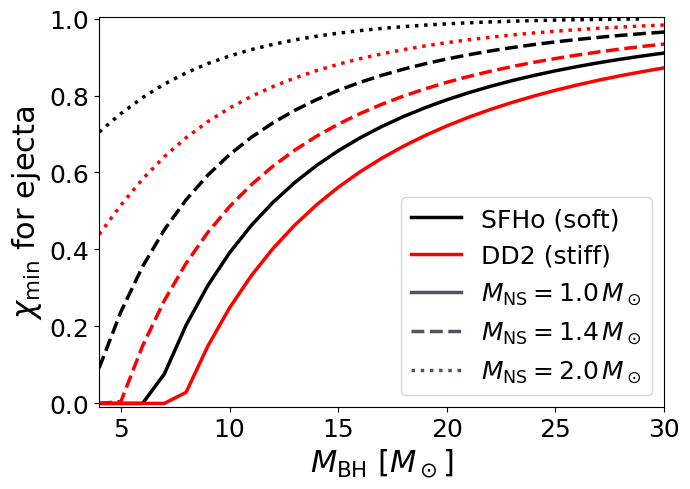

In [5]:
# ============================================================================
# Visualization of threshold spin vs integer BH mass for fixed-NS cases
# ============================================================================

# Case 2 parameters
target_case2    = 0.5
mns_case2       = 1.4

# Case 3 parameters
target_case3    = 0.9
mns_case3       = 2.0

# Case 1
mns_case1       = 1.0
target_case1    = 0.0  # already satisfied by M_BH=5

case1_df, case1_sum = scan_integer_bh_masses(mns_case1, target_case1, mbh_min=4, mbh_max=30)
case2_df, case2_sum = scan_integer_bh_masses(mns_case2, target_case2, mbh_min=4, mbh_max=30)
case3_df, case3_sum = scan_integer_bh_masses(mns_case3, target_case3, mbh_min=4, mbh_max=30)

FONTSIZE    = 22

# Case 1 plot: M_NS = 1.0
plt.figure(figsize=(7, 5))
plt.plot(case1_df["M_BH"], case1_df["chi_min_SFHO"], color="black", linewidth=2.5)
plt.plot(case1_df["M_BH"], case1_df["chi_min_DD2"], color="red", linewidth=2.5)
plt.plot(case2_df["M_BH"], case2_df["chi_min_SFHO"], color="black", linewidth=2.5, linestyle="--")
plt.plot(case2_df["M_BH"], case2_df["chi_min_DD2"], color="red", linewidth=2.5, linestyle="--")
plt.plot(case3_df["M_BH"], case3_df["chi_min_SFHO"], color="black", linewidth=2.5, linestyle=":")
plt.plot(case3_df["M_BH"], case3_df["chi_min_DD2"], color="red", linewidth=2.5, linestyle=":")
plt.xlabel("$M_\\text{BH}$ [$M_\\odot$]", fontsize=FONTSIZE)
plt.ylabel("$\\chi_\\text{min}$ for ejecta", fontsize=FONTSIZE)
plt.ylim(-0.01, 1.005)
plt.xlim(4, 30)
plt.tick_params(axis='both', which='major', labelsize=FONTSIZE-4)
COLOR_STYLE = "#4b5563"
# colors for EOS, linestyles for cases so 5 total legend handles
color_handless = [plt.Line2D([0], [0], color="black", linewidth=2.5),
                 plt.Line2D([0], [0], color="red", linewidth=2.5),
                 plt.Line2D([0], [0], color=COLOR_STYLE, linewidth=2.5, linestyle="-"),
                plt.Line2D([0], [0], color=COLOR_STYLE, linewidth=2.5, linestyle="--"),
                plt.Line2D([0], [0], color=COLOR_STYLE, linewidth=2.5, linestyle=":")]

leg = plt.legend(handles=color_handless, 
                 labels=[
                    "SFHo (soft)", "DD2 (stiff)", 
                    f"$M_\\text{{NS}} = {mns_case1}\\,M_\\odot$", 
                    f"$M_\\text{{NS}} = {mns_case2}\\,M_\\odot$", 
                    f"$M_\\text{{NS}} = {mns_case3}\\,M_\\odot$"
                    ],
                 loc="lower right", fontsize=FONTSIZE-4)
                 

plt.tight_layout()
plt.savefig("disruption_threshold_scan_all.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [6]:

print("\n" + "=" * 70)
print("CHIRP MASS ANALYSIS")
print("=" * 70)

# Helper function: compute chirp mass span for systems with ejecta at target spin
def chirp_span(df, chi_col, target):
    """Return (min, max) chirp mass for systems with χ_min ≤ target."""
    ok = df[np.isfinite(df[chi_col]) & (df[chi_col] <= target)]
    if ok.empty:
        return np.nan, np.nan
    return ok["M_chirp"].min(), ok["M_chirp"].max()

# Find minimum BH mass threshold for disruption at target spin
def min_bh_for_disruption(df, chi_col, target):
    """Return minimum M_BH where χ_min ≤ target."""
    ok = df[np.isfinite(df[chi_col]) & (df[chi_col] <= target)]
    if ok.empty:
        return np.nan
    return ok["M_BH"].min()

# Compute for both cases
c2_sfho_span    = chirp_span(case2_df, "chi_min_SFHO", target_case2)
c2_dd2_span     = chirp_span(case2_df, "chi_min_DD2", target_case2)
c3_sfho_span    = chirp_span(case3_df, "chi_min_SFHO", target_case3)
c3_dd2_span     = chirp_span(case3_df, "chi_min_DD2", target_case3)

c2_sfho_min_bh  = min_bh_for_disruption(case2_df, "chi_min_SFHO", target_case2)
c2_dd2_min_bh   = min_bh_for_disruption(case2_df, "chi_min_DD2", target_case2)
c3_sfho_min_bh  = min_bh_for_disruption(case3_df, "chi_min_SFHO", target_case3)
c3_dd2_min_bh   = min_bh_for_disruption(case3_df, "chi_min_DD2", target_case3)

print("\nChirp-mass span for systems with ejecta at target spin:")
print(f"\nCase 2 (target χ={target_case2}):")
print(f"  SFHo: M_chirp ∈ {c2_sfho_span}, requires M_BH ≥ {c2_sfho_min_bh:.0f}")
print(f"  DD2:  M_chirp ∈ {c2_dd2_span}, requires M_BH ≥ {c2_dd2_min_bh:.0f}")

print(f"\nCase 3 (target χ={target_case3}):")
print(f"  SFHo: M_chirp ∈ {c3_sfho_span}, requires M_BH ≥ {c3_sfho_min_bh:.0f}")
print(f"  DD2:  M_chirp ∈ {c3_dd2_span}, requires M_BH ≥ {c3_dd2_min_bh:.0f}")


CHIRP MASS ANALYSIS

Chirp-mass span for systems with ejecta at target spin:

Case 2 (target χ=0.5):
  SFHo: M_chirp ∈ (2.006476438221742, 2.5696844010948974), requires M_BH ≥ 4
  DD2:  M_chirp ∈ (2.006476438221742, 2.8629624978916928), requires M_BH ≥ 4

Case 3 (target χ=0.9):
  SFHo: M_chirp ∈ (2.433457367572823, 3.5065898067639023), requires M_BH ≥ 4
  DD2:  M_chirp ∈ (2.433457367572823, 4.487820581784797), requires M_BH ≥ 4


### References

- **Primary Methodology:** Colombo et al. (2024)
  
- **Foucart Fitting Formulae:**
  - **Foucart (2018)** — Remnant baryon mass [PRIMARY THRESHOLD MODEL IN THIS NOTEBOOK]
    - Uses eta=q/(1+q)^2 to extend high-Q arguments to moderate mass ratios
    - Coefficients: alpha=0.406, beta=0.139, gamma=0.255, delta=1.761
  - **Foucart (2020)** — Dynamical ejecta mass [COMPLEMENTARY DIAGNOSTIC]
    - Krüger & Foucart (2020), Phys. Rev. D **101**, 103002 [arXiv:2002.07728](https://arxiv.org/abs/2002.07728)
  
- **Equations of State:**
  - SFHo: Hempel & Schaffner-Bielich (2010); Steiner, Hempel & Fischer (2013)
  - DD2: Typel, Röpke, Klähn, Blaschke & Wolter (2010)
  
- **ISCO Formula:** Bardeen, Press & Teukolsky (1972) for Kerr black holes

# Love Number

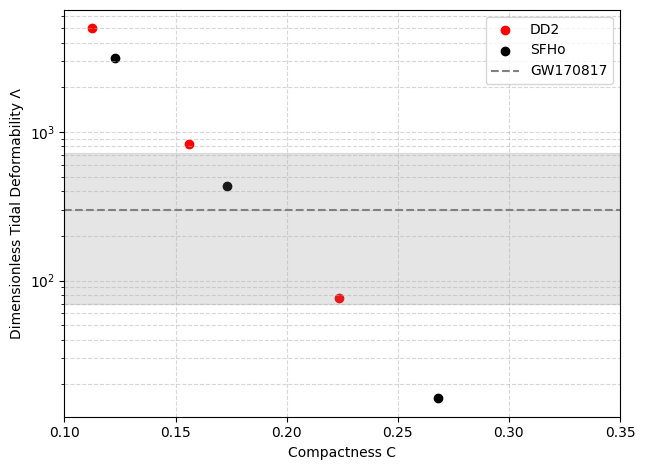

In [7]:
import numpy as np
from scipy.optimize import root_scalar

# Coefficients from Godzieba et al. 2021, Table II (C - Lambda2 fit)
coeffs = np.array([0.3388,
                   -2.30e-2,
                   -4.651e-4,
                   -2.636e-4,
                   5.424e-5,
                   -3.188e-6,
                   6.181e-8])

def C_from_lnL(lnL):
    """Compute compactness C from ln(Lambda) using polynomial fit."""
    return np.polyval(coeffs[::-1], lnL)  # polyval expects highest degree first

def Lambda_from_C(C, bracket=(1, 15), verbose=False):
    """
    Compute dimensionless tidal deformability Lambda from compactness C.
    
    Parameters
    ----------
    C : float
        Compactness (M/R in geometric units, 0 < C < 0.35 typically).
    bracket : tuple
        Initial bracket for ln(Lambda); default (1,15) covers Lambda ~ 2.7 to 3e6.
    verbose : bool
        If True, print solver details.
    
    Returns
    -------
    Lambda : float
        Dimensionless tidal deformability.
    """
    def func(lnL):
        return C_from_lnL(lnL) - C
    
    sol = root_scalar(func, bracket=bracket, method='bisect', xtol=1e-12)
    if verbose:
        print(sol)
    return np.exp(sol.root)

Lambda_dd2 = [Lambda_from_C(c) for c in C_dd2_dimless]
Lambda_sfho = [Lambda_from_C(c) for c in C_sfho_dimless]

plt.scatter(C_dd2_dimless, Lambda_dd2, label="DD2", color="red")
plt.scatter(C_sfho_dimless, Lambda_sfho, label="SFHo", color="black")
plt.yscale("log")
plt.xlabel("Compactness C") 
plt.ylabel("Dimensionless Tidal Deformability Λ")
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
#range GW170817
min_range = 300-230
median = 300
max_range = 300+420
plt.axhline(median, color="gray", linestyle="--", label="GW170817")
plt.fill_betweenx([min_range, max_range], 0, 0.35, color="gray", alpha=0.2)
plt.xlim(0.1, 0.35)
plt.legend()
plt.show()

In [8]:
def make_lambda_latex_table(masses, c_sfho, lambda_sfho, c_dd2, lambda_dd2):
    """Format the computed Lambda values into a LaTeX table."""
    lines = []
    lines.append(r"\begin{table}[htbp]")
    lines.append(r"  \centering")
    lines.append(r"  \caption{Dimensionless tidal deformability $\Lambda$ computed from neutron star compactness $C$.}")
    lines.append(r"  \label{tab:tidal_deformability}")
    lines.append(r"  \begin{tabular}{ccccc}")
    lines.append(r"    \toprule")
    lines.append(r"    $M_{\mathrm{NS}}$ ($M_\odot$) & $C_{\mathrm{SFHo}}$ & $\Lambda_{\mathrm{SFHo}}$ & $C_{\mathrm{DD2}}$ & $\Lambda_{\mathrm{DD2}}$ \\")
    lines.append(r"    \midrule")

    for m, c_s, l_s, c_d, l_d in zip(masses, c_sfho, lambda_sfho, c_dd2, lambda_dd2):
        # Clip max mass marking logic similarly to before if desired
        m_str = f"{m:.2f}"
        if m > max_mass_sfho or m > max_mass_dd2:
            m_str = f"{m_str}$^{{*}}$"
            
        lines.append(
            f"    {m_str} & {c_s:.4f} & {l_s:.0f} & {c_d:.4f} & {l_d:.0f} \\\\"
        )

    lines.append(r"    \bottomrule")
    lines.append(r"  \end{tabular}")
    lines.append(r"\end{table}")
    return "\n".join(lines)

print("LaTeX table for Tidal Deformability:")
print(make_lambda_latex_table(ns_masses, C_sfho_dimless, Lambda_sfho, C_dd2_dimless, Lambda_dd2))

LaTeX table for Tidal Deformability:
\begin{table}[htbp]
  \centering
  \caption{Dimensionless tidal deformability $\Lambda$ computed from neutron star compactness $C$.}
  \label{tab:tidal_deformability}
  \begin{tabular}{ccccc}
    \toprule
    $M_{\mathrm{NS}}$ ($M_\odot$) & $C_{\mathrm{SFHo}}$ & $\Lambda_{\mathrm{SFHo}}$ & $C_{\mathrm{DD2}}$ & $\Lambda_{\mathrm{DD2}}$ \\
    \midrule
    1.00 & 0.1226 & 3160 & 0.1126 & 4970 \\
    1.40 & 0.1734 & 436 & 0.1559 & 829 \\
    2.00 & 0.2683 & 16 & 0.2238 & 76 \\
    \bottomrule
  \end{tabular}
\end{table}
